# Random Forest Sybil Detector — LayerZero (baseline, A13)

A tuned Random Forest, selected the same way as XGBoost and LightGBM (`02_hyperparameter_search`), so the
comparison with the boosted models rests on results rather than on an argument (tracker item A13, R2).

**Protocol**
- **Part A, search (validation only).** Stratified group split, seed `sp.SEED`; the test partition is deleted
  before any fit. `RandomForestClassifier(n_estimators=300, criterion='gini', bootstrap=True)`, no
  `class_weight` (the training partition is already upsampled to 1:1). Grid: `max_features` {`'sqrt'`, 0.3, 0.5,
  0.7} × `min_samples_leaf` {1, 5, 20} × `max_depth` {None, 24}, 24 configurations, one fit each (seed 42). The
  first run searched `'sqrt'` and 0.3 only (12 configurations); 0.3 was selected at the edge of that grid, so the
  grid was extended to 0.5 and 0.7.
  **Selection**: validation F1 at the F1-maximising validation threshold, ties broken by validation AP (as in `02`).
  Each configuration is written to `results/13_search_random_forest.csv` as it finishes, so an interrupted run
  resumes where it stopped.
- **Memory guard.** One fully grown tree is fitted first and its pickled size projected to 300 trees. If the
  projection exceeds 50 % of available RAM, `max_samples=0.5` is added to *every* configuration.
- **Part B, final model.** The selected configuration with each seed in `sp.MODEL_SEEDS`; probabilities
  averaged, as `sp.fit_lgbm` does. Threshold chosen on validation; test reported once.
- **Part C, split variability.** The selected configuration (model seed 42) on the 10 group splits in
  `sp.SPLIT_SEEDS`, against LightGBM (selected parameters, model seed 42, `sp.lgbm_fit_eval`) trained on the
  same splits in this notebook, so the paired comparison is on one machine. `08_ablation_families` → "All
  features" is shown too, labeled as coming from another machine.

**Results**: `results/13_random_forest_sybil.json`; predictions in `output/`.

## Setup

In [1]:
import os, platform, time, itertools, pickle, warnings
import numpy as np
import pandas as pd
import psutil
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score, log_loss
import sybil_pipeline as sp
warnings.filterwarnings('ignore')
assert not sp.CODE_COMMIT.endswith('-dirty'), f'Run from a clean working tree (CODE_COMMIT={sp.CODE_COMMIT})'
print('Code commit:', sp.CODE_COMMIT)
PLATFORM = dict(machine=platform.machine(), processor=platform.processor(), system=platform.system(),
                python=platform.python_version(), cpu_count=os.cpu_count(), n_jobs=sp.N_JOBS)
print('Platform:', PLATFORM)
MAX_FEATURES = ['sqrt', 0.3, 0.5, 0.7]

DATA_DIR = './data'
RESULTS_DIR = './results'
FEATS = sp.FEATS   # 62 model features (defined in sybil_pipeline.py)
N_TREES = 300
SEARCH_CSV = os.path.join(RESULTS_DIR, '13_search_random_forest.csv')
RF_FIXED = dict(n_estimators=N_TREES, criterion='gini', bootstrap=True, n_jobs=sp.N_JOBS)

def rf_model(cfg, seed):
    """Random Forest with the fixed settings; `cfg` holds the searched hyperparameters."""
    return RandomForestClassifier(**RF_FIXED, random_state=seed, **cfg)

Code commit: 2adac1c
Platform: {'machine': 'x86_64', 'processor': 'x86_64', 'system': 'Linux', 'python': '3.11.15', 'cpu_count': 4, 'n_jobs': 4}


## Part A. Validation-only search

Same split as `02`; the test partition is removed before any model is fitted.

In [2]:
df, _, _ = sp.build_master_df(DATA_DIR)
S = sp.make_splits(df, FEATS, method='group', seed=sp.SEED)
for k in ['X_test', 'y_test', 'idx_test']:
    del S[k]                    # test partition is not available to the search
X_train, y_train = S['X_train'], S['y_train']
X_val, y_val = S['X_val'], S['y_val']
print(sp.split_summary(df, {**S, 'idx_test': []}).iloc[:2].to_string(index=False))
print(f"Train after upsampling: {len(X_train):,} rows ({y_train.mean()*100:.1f}% Sybil)")

[1] L0 features: 434,786 addresses, 55 cols


[2] Gas provision: 604,365 edges before 2024-05-02 00:00:00 UTC (296 later edges dropped)


[3] Labeled addresses in provision network: 4,308


[4] Provider and tree features: 88 cols


[5] CEX/DEX merged: 90 cols


[6] Labels: Sybil=18,211 (4.19%)


[7] Chain features, taxonomy, gas provision trees (371,764 trees)


All 62 features present ✓  (59.8s)


     Split  Total  Sybil  NonSybil  SybilPct
     Train 213046   8924    204122      4.19
Validation  91305   3824     87481      4.19
Train after upsampling: 408,244 rows (50.0% Sybil)


### Memory guard

Fully grown trees (`min_samples_leaf=1`, `max_depth=None`) are the largest. One such tree per `max_features`
value is fitted and pickled; the larger size is projected to 300 trees.

In [3]:
probe_bytes = {}
for mf in MAX_FEATURES:
    t0 = time.time()
    probe = RandomForestClassifier(n_estimators=1, criterion='gini', bootstrap=True, n_jobs=1,
                                   random_state=sp.SEED, max_features=mf, min_samples_leaf=1, max_depth=None)
    probe.fit(X_train, y_train)
    probe_bytes[str(mf)] = len(pickle.dumps(probe))
    print(f"max_features={mf!s:<5} one tree: {probe_bytes[str(mf)]/2**20:,.1f} MiB, "
          f"{probe.estimators_[0].tree_.node_count:,} nodes, {time.time()-t0:.1f}s")
    del probe
projected = N_TREES * max(probe_bytes.values())
available = psutil.virtual_memory().available
MAX_SAMPLES = 0.5 if projected > 0.5 * available else None
memory_guard = dict(one_tree_bytes=probe_bytes, projected_forest_bytes=int(projected),
                    available_ram_bytes=int(available), max_samples=MAX_SAMPLES,
                    rule='max_samples=0.5 for every configuration if 300 x the largest fully grown tree > 50% of available RAM')
print(f"Projected 300-tree forest: {projected/2**30:.2f} GiB; available RAM {available/2**30:.2f} GiB "
      f"-> max_samples = {MAX_SAMPLES}")

max_features=sqrt  one tree: 1.1 MiB, 14,397 nodes, 1.5s


max_features=0.3   one tree: 0.9 MiB, 11,841 nodes, 3.9s


max_features=0.5   one tree: 0.8 MiB, 10,765 nodes, 6.4s


max_features=0.7   one tree: 0.8 MiB, 10,657 nodes, 8.7s
Projected 300-tree forest: 0.32 GiB; available RAM 14.10 GiB -> max_samples = None


In [4]:
GRID = [dict(max_features=mf, min_samples_leaf=leaf, max_depth=depth, max_samples=MAX_SAMPLES)
        for mf, leaf, depth in itertools.product(MAX_FEATURES, [1, 5, 20], [None, 24])]
KEYS = list(GRID[0])
cfg_key = lambda cfg: tuple(str(cfg[k]) for k in KEYS)   # CSV-safe identity of a configuration

def val_scores(probs):
    thr = sp.best_f1_threshold(y_val, probs)
    return dict(val_f1=f1_score(y_val, (probs >= thr).astype(int)),
                val_ap=average_precision_score(y_val, probs),
                val_auroc=roc_auc_score(y_val, probs),
                val_logloss=log_loss(y_val, np.clip(probs, 1e-15, 1 - 1e-15)), val_threshold=thr)

done = pd.read_csv(SEARCH_CSV, dtype={k: str for k in KEYS}, keep_default_na=False) if os.path.exists(SEARCH_CSV) else pd.DataFrame()
seen = set(map(tuple, done[KEYS].values)) if len(done) else set()
print(f'{len(seen)} of {len(GRID)} configurations already in {SEARCH_CSV}')
t_first = None
for i, cfg in enumerate(GRID, 1):
    if cfg_key(cfg) in seen:
        continue
    assert 'X_test' not in S and 'y_test' not in S   # the search never sees the test partition
    t0 = time.time()
    m = rf_model(cfg, sp.SEED)
    m.fit(X_train, y_train)
    probs = m.predict_proba(X_val)[:, 1]
    del m
    row = {**{k: str(cfg[k]) for k in KEYS}, **val_scores(probs), 'seconds': round(time.time() - t0, 1)}
    done = pd.concat([done, pd.DataFrame([row])], ignore_index=True)
    done.to_csv(SEARCH_CSV, index=False)
    if t_first is None:
        t_first = row['seconds']
        left = sum(cfg_key(c) not in seen for c in GRID) - 1
        print(f'  first fit {t_first:.0f}s; about {t_first * left / 60:.0f} min for the remaining {left} '
              f'(the 3 final fits and 10 split fits take about {t_first * 13 / 60:.0f} min more)', flush=True)
    print(f"[{i}/{len(GRID)}] {cfg}  val_F1={row['val_f1']:.4f}  AP={row['val_ap']:.4f}  {row['seconds']}s", flush=True)

0 of 24 configurations already in ./results/13_search_random_forest.csv


  first fit 117s; about 45 min for the remaining 23 (the 3 final fits and 10 split fits take about 25 min more)


[1/24] {'max_features': 'sqrt', 'min_samples_leaf': 1, 'max_depth': None, 'max_samples': None}  val_F1=0.6981  AP=0.7465  117.0s


[2/24] {'max_features': 'sqrt', 'min_samples_leaf': 1, 'max_depth': 24, 'max_samples': None}  val_F1=0.6174  AP=0.6515  103.9s


[3/24] {'max_features': 'sqrt', 'min_samples_leaf': 5, 'max_depth': None, 'max_samples': None}  val_F1=0.6729  AP=0.7186  109.5s


...

[20/24] {'max_features': 0.7, 'min_samples_leaf': 1, 'max_depth': 24, 'max_samples': None}  val_F1=0.6384  AP=0.6615  582.0s


[21/24] {'max_features': 0.7, 'min_samples_leaf': 5, 'max_depth': None, 'max_samples': None}  val_F1=0.6973  AP=0.7381  617.1s


[22/24] {'max_features': 0.7, 'min_samples_leaf': 5, 'max_depth': 24, 'max_samples': None}  val_F1=0.6468  AP=0.6760  615.6s


[23/24] {'max_features': 0.7, 'min_samples_leaf': 20, 'max_depth': None, 'max_samples': None}  val_F1=0.6784  AP=0.7208  633.8s


[24/24] {'max_features': 0.7, 'min_samples_leaf': 20, 'max_depth': 24, 'max_samples': None}  val_F1=0.6558  AP=0.6867  590.9s


In [5]:
grid_keys = {cfg_key(c) for c in GRID}
search = done[[tuple(r) in grid_keys for r in done[KEYS].values]].reset_index(drop=True)   # rows of this grid only
assert len(search) == len(GRID) and set(map(tuple, search[KEYS].values)) == grid_keys
ranked = search.sort_values(['val_f1', 'val_ap'], ascending=False).reset_index(drop=True)
best_key = tuple(ranked.loc[0, KEYS])
RF_SELECTED = next(c for c in GRID if cfg_key(c) == best_key)
SELECTION_RULE = 'max validation F1 at validation-optimal threshold; ties by validation AP; seed 42'
print('Selected Random Forest config:', RF_SELECTED)
print(ranked.round(4).to_string(index=False))

Selected Random Forest config: {'max_features': 0.3, 'min_samples_leaf': 1, 'max_depth': None, 'max_samples': None}
max_features min_samples_leaf max_depth max_samples  val_f1  val_ap  val_auroc  val_logloss  val_threshold  seconds
         0.3                1      None        None  0.7051  0.7506     0.9673       0.0824         0.3500    274.6
         0.5                1      None        None  0.7024  0.7469     0.9648       0.0856         0.3733    485.8
         0.7                1      None        None  0.6994  0.7411     0.9634       0.0869         0.3633    672.0
        sqrt                1      None        None  0.6981  0.7465     0.9666       0.0802         0.3196    117.0
         0.5                5      None        None  0.6980  0.7417     0.9668       0.0886         0.5348    458.2
         0.7                5      None        None  0.6973  0.7381     0.9646       0.0908         0.5977    617.1
         0.3                5      None        None  0.6970  0.7416     

### Marginal effect of each hyperparameter (best validation F1 over configurations with that value)

In [6]:
print(pd.DataFrame([dict(param=p, value=v, best_val_f1=round(f, 4))
                    for p in ['max_features', 'min_samples_leaf', 'max_depth']
                    for v, f in search.groupby(p)['val_f1'].max().items()]).to_string(index=False))
if RF_SELECTED['max_features'] == MAX_FEATURES[-1]:
    print('Note: the selection is at the edge of the grid (max_features = 0.7)')

           param value  best_val_f1
    max_features   0.3       0.7051
    max_features   0.5       0.7024
    max_features   0.7       0.6994
    max_features  sqrt       0.6981
min_samples_leaf     1       0.7051
min_samples_leaf    20       0.6803
min_samples_leaf     5       0.6980
       max_depth    24       0.6558
       max_depth  None       0.7051


## Part B. Final model (3 seeds) and test evaluation

The split is rebuilt with the test partition. Threshold: the F1-maximizing threshold on validation.

In [7]:
S = sp.make_splits(df, FEATS, method='group', seed=sp.SEED)   # asserts no gas provision tree spans two partitions
print(sp.split_summary(df, S).to_string(index=False))
leak = sp.leakage_report(df, S)
val_p, test_p = [], []
for seed in sp.MODEL_SEEDS:
    t0 = time.time()
    m = rf_model(RF_SELECTED, seed)
    m.fit(S['X_train'], S['y_train'])
    val_p.append(m.predict_proba(S['X_val'])[:, 1]); test_p.append(m.predict_proba(S['X_test'])[:, 1])
    del m
    print(f'  Random Forest seed={seed}  {time.time() - t0:.1f}s', flush=True)
val, test = np.mean(val_p, axis=0), np.mean(test_p, axis=0)

     Split  Total  Sybil  NonSybil  SybilPct
     Train 213046   8924    204122      4.19
Validation  91305   3824     87481      4.19
      Test 130435   5463    124972      4.19


Split method: group
Row overlap (train/val, train/test, val/test): 0, 0, 0
Test addresses sharing a gas provision tree with a train address: 0 / 130,435
Test Sybils sharing a gas provision tree with a train Sybil:     0 / 5,463


  Random Forest seed=42  285.0s


  Random Forest seed=123  283.7s


  Random Forest seed=456  282.4s


  Threshold : 0.3500
  Precision : 0.7227
  Recall    : 0.7007
  F1        : 0.7115
  AUROC     : 0.9709
  Avg Prec  : 0.7689
  Brier     : 0.0176


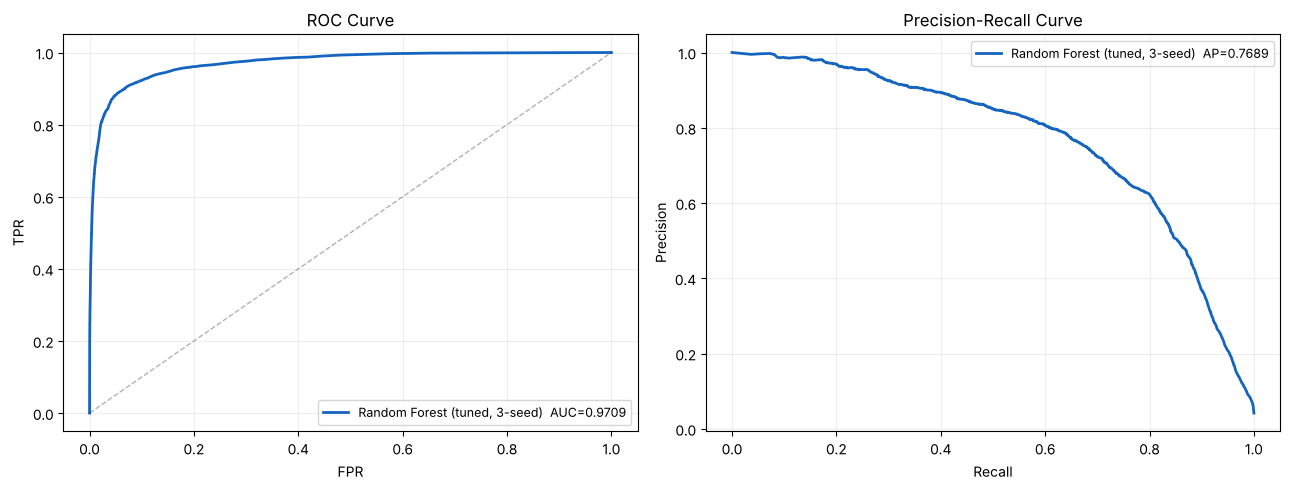

In [8]:
res = sp.evaluate('Random Forest (tuned, 3-seed)', S['y_val'], val, S['y_test'], test)
sp.print_metrics(res)
assert res['threshold'] == sp.best_f1_threshold(S['y_val'], val)   # threshold comes from validation
sp.plot_curves([res])

### Operating points and per-category metrics (test)

In [9]:
ops = sp.operating_points(S['y_test'], test, res['threshold'])
print(ops.round(4).to_string(index=False))
by_cat = sp.metrics_by_category(S['y_test'], test, df.loc[S['idx_test'], 'category'], res['threshold'])
print(by_cat.round(4).to_string(index=False))
assert by_cat['n'].sum() == len(S['y_test']) == 130_435
assert by_cat['sybil'].sum() == int(S['y_test'].sum()) == 5_463

 threshold  precision  recall     f1  flagged  false_pos                 note
      0.95     0.9683  0.2010 0.3329     1134         36                     
      0.90     0.9385  0.2793 0.4305     1626        100                     
      0.85     0.9075  0.3485 0.5036     2098        194                     
      0.80     0.8926  0.4045 0.5567     2476        266                     
      0.75     0.8716  0.4523 0.5956     2835        364                     
      0.70     0.8502  0.4988 0.6287     3205        480                     
      0.50     0.7920  0.6271 0.7000     4326        900                     
      0.35     0.7227  0.7007 0.7115     5297       1469 validation threshold


   category     n  sybil  precision  recall     f1  auroc    fpr
        IxE 28171    258     0.8113  0.1667 0.2765 0.9382 0.0004
        IxI  9967    426     0.9400  0.1103 0.1975 0.9234 0.0003
        IxL 92079   4770     0.7194  0.7822 0.7495 0.9754 0.0167
No provider   218      9     0.8750  0.7778 0.8235 0.9968 0.0048


## Part C. Split variability (10 group splits, model seed 42)

LightGBM (selected parameters from `02`, model seed 42) is trained on the same 10 splits here, so the paired
differences are computed on one machine. `08_ablation_families` → "All features" ran the same LightGBM on another
machine; it is shown for reference only.

In [10]:
_, LGBM_SELECTED = sp.load_selected_params()
rows = []
for s in sp.SPLIT_SEEDS:
    t0 = time.time()
    Sc = sp.make_splits(df, FEATS, method='group', seed=s)
    lg = sp.lgbm_fit_eval(Sc, FEATS, LGBM_SELECTED)   # same-machine LightGBM baseline, model seed 42
    m = rf_model(RF_SELECTED, 42)
    m.fit(Sc['X_train'], Sc['y_train'])
    pv, pt = m.predict_proba(Sc['X_val'])[:, 1], m.predict_proba(Sc['X_test'])[:, 1]
    del m
    thr = sp.best_f1_threshold(Sc['y_val'], pv)
    row = dict(split_seed=s, threshold=thr)
    for part, y, p in [('val', Sc['y_val'], pv), ('test', Sc['y_test'], pt)]:
        row[f'{part}_f1'] = f1_score(y, (p >= thr).astype(int))
        row[f'{part}_ap'] = average_precision_score(y, p)
        row[f'{part}_auroc'] = roc_auc_score(y, p)
    row.update({f'lgbm_{k}': v for k, v in lg.items()})
    rows.append(row)
    print(f"split {s}: RF test F1 {row['test_f1']:.4f}  AP {row['test_ap']:.4f}; LightGBM {lg['test_f1']:.4f} / "
          f"{lg['test_ap']:.4f}  ({time.time() - t0:.0f}s)", flush=True)
per_split = pd.DataFrame(rows)
assert len(per_split) == 10 and per_split['split_seed'].is_unique

lgbm08 = pd.DataFrame(sp.load_results('08_ablation_families')['per_split'])
lgbm08 = lgbm08[lgbm08['config'] == 'All features'].set_index('split_seed')
for k in ['test_f1', 'test_ap', 'test_auroc']:
    per_split[f'{k}_minus_lgbm'] = per_split[k] - per_split[f'lgbm_{k}']                       # same machine
    per_split[f'{k}_minus_lgbm08'] = per_split[k] - per_split['split_seed'].map(lgbm08[k])     # other machine
per_split['lgbm_test_f1_minus_lgbm08'] = per_split['lgbm_test_f1'] - per_split['split_seed'].map(lgbm08['test_f1'])
metric_cols = [c for c in per_split.columns if c != 'split_seed']
summary = {f'{c}_{a}': float(getattr(per_split[c], a)()) for c in metric_cols for a in ('mean', 'std')}
summary['test_f1_lower_than_lgbm_n'] = int((per_split['test_f1_minus_lgbm'] < 0).sum())
summary['test_f1_lower_than_lgbm08_n'] = int((per_split['test_f1_minus_lgbm08'] < 0).sum())
summary['lgbm_reproduces_08'] = bool((per_split['lgbm_test_f1_minus_lgbm08'].abs() < 1e-12).all())
print(per_split.round(4).to_string(index=False))

split 42: RF test F1 0.7112  AP 0.7648; LightGBM 0.7175 / 0.7680  (328s)


split 1: RF test F1 0.6992  AP 0.7415; LightGBM 0.6924 / 0.7512  (341s)


split 2: RF test F1 0.7010  AP 0.7475; LightGBM 0.7142 / 0.7577  (348s)


split 3: RF test F1 0.6932  AP 0.7522; LightGBM 0.7109 / 0.7632  (348s)


split 4: RF test F1 0.7023  AP 0.7575; LightGBM 0.7076 / 0.7559  (352s)


...

split 6: RF test F1 0.6992  AP 0.7457; LightGBM 0.6971 / 0.7491  (347s)


split 7: RF test F1 0.7084  AP 0.7644; LightGBM 0.7106 / 0.7700  (337s)


split 8: RF test F1 0.7056  AP 0.7575; LightGBM 0.7177 / 0.7677  (335s)


split 9: RF test F1 0.7041  AP 0.7550; LightGBM 0.7053 / 0.7623  (343s)


 split_seed  threshold  val_f1  val_ap  val_auroc  test_f1  test_ap  test_auroc  lgbm_threshold  lgbm_val_f1  lgbm_val_ap  lgbm_val_auroc  lgbm_test_f1  lgbm_test_ap  lgbm_test_auroc  test_f1_minus_lgbm  test_f1_minus_lgbm08  test_ap_minus_lgbm  test_ap_minus_lgbm08  test_auroc_minus_lgbm  test_auroc_minus_lgbm08  lgbm_test_f1_minus_lgbm08
         42     0.3500  0.7051  0.7506     0.9673   0.7112   0.7648      0.9695          0.6157       0.7046       0.7561          0.9679        0.7175        0.7680           0.9696             -0.0063               -0.0063             -0.0032               -0.0032                -0.0001                  -0.0001                        0.0
          1     0.3833  0.7184  0.7644     0.9703   0.6992   0.7415      0.9679          0.7214       0.7143       0.7653          0.9682        0.6924        0.7512           0.9689              0.0068                0.0068             -0.0097               -0.0097                -0.0010                  -0.0010  

## Comparison with the other models

In [11]:
cols = ['precision', 'recall', 'f1', 'auroc', 'ap']
others = [sp.load_results(nb)['models'][0] for nb in ['03_xgboost_sybil', '04_lightgbm_sybil', '05_logistic_regression_sybil']]
table = pd.DataFrame([{'model': r['name'], **{c: r[c] for c in cols}} for r in others + [res]])
print('Test partition, seed-42 group split (03-05 from their committed results):')
print(table.round(4).to_string(index=False))

s08 = sp.load_results('08_ablation_families')['summary']['All features']
p08 = sp.load_results('08_ablation_families').get('platform', 'not recorded; the machine of the committed results')
print(f"\n10 group splits, model seed 42 (mean ± SD); this notebook: {PLATFORM['machine']} / {PLATFORM['system']}")
fmt = lambda d, pre: {m: f"{d[f'{pre}test_{m}_mean']:.4f} ± {d[f'{pre}test_{m}_std']:.4f}" for m in ['f1', 'ap', 'auroc']}
print(pd.DataFrame([dict(model='Random Forest (selected), this machine', **fmt(summary, '')),
                    dict(model='LightGBM, this machine', **fmt(summary, 'lgbm_')),
                    dict(model=f'LightGBM, 08 (platform: {p08})', **fmt(s08, ''))]).to_string(index=False))
print(f"RF − LightGBM, paired by split, same machine: test F1 {summary['test_f1_minus_lgbm_mean']:+.4f} ± "
      f"{summary['test_f1_minus_lgbm_std']:.4f} (RF lower on {summary['test_f1_lower_than_lgbm_n']} of 10); "
      f"AP {summary['test_ap_minus_lgbm_mean']:+.4f} ± {summary['test_ap_minus_lgbm_std']:.4f}; "
      f"AUROC {summary['test_auroc_minus_lgbm_mean']:+.4f} ± {summary['test_auroc_minus_lgbm_std']:.4f}")
print(f"LightGBM here minus 08 (platform difference), test F1: {summary['lgbm_test_f1_minus_lgbm08_mean']:+.4f} ± "
      f"{summary['lgbm_test_f1_minus_lgbm08_std']:.4f}; identical: {summary['lgbm_reproduces_08']}")

Test partition, seed-42 group split (03-05 from their committed results):
                           model  precision  recall     f1  auroc     ap
         XGBoost (tuned, 3-seed)     0.7103  0.7216 0.7159 0.9695 0.7643
        LightGBM (tuned, 3-seed)     0.7025  0.7276 0.7149 0.9696 0.7693
Logistic Regression (C=0.01, L1)     0.1559  0.5219 0.2400 0.8376 0.1668
   Random Forest (tuned, 3-seed)     0.7227  0.7007 0.7115 0.9709 0.7689

10 group splits, model seed 42 (mean ± SD); this notebook: x86_64 / Linux
                                                                      model              f1              ap           auroc
                                     Random Forest (selected), this machine 0.7023 ± 0.0052 0.7537 ± 0.0077 0.9689 ± 0.0014
                                                     LightGBM, this machine 0.7086 ± 0.0083 0.7606 ± 0.0071 0.9688 ± 0.0019
LightGBM, 08 (platform: not recorded; the machine of the committed results) 0.7086 ± 0.0083 0.7606 ± 0.0071 0.9688

## Save results

Scalar metrics, the selected configuration, the search size and rule, operating points, per-category metrics
and the 10-split rows go to `results/13_random_forest_sybil.json` with the code commit. Validation and test
probabilities go to `output/`.

In [12]:
sp.save_results([res], '13_random_forest_sybil', leakage=leak, extra=dict(
    params={**RF_SELECTED, **RF_FIXED}, memory_guard=memory_guard, n_configs=len(GRID),
    selection_rule=SELECTION_RULE,
    selected_val=dict(val_f1=float(ranked.loc[0, 'val_f1']), val_ap=float(ranked.loc[0, 'val_ap'])),
    operating_points=ops.to_dict('records'), by_category=by_cat.to_dict('records'),
    per_split=per_split.to_dict('records'), summary=summary, rounds_or_trees=N_TREES,
    lgbm_params=LGBM_SELECTED, platform=PLATFORM))
sp.save_predictions(df, S, '13_random_forest_sybil', prob_rf=dict(val=val, test=test))

Saved results/13_random_forest_sybil.json
Saved output/pred_13_random_forest_sybil_val.parquet (91,305 rows)


Saved output/pred_13_random_forest_sybil_test.parquet (130,435 rows)
